
# 🚢 Titanic Survival Prediction — Complete Machine Learning Project

This Google Colab notebook answers:

> **What is the probability that a Titanic passenger survives or does not survive?**

### Important clarification
The dataset does **not** predict whether the ship will sink.  
The Titanic already sank historically. This project predicts a **passenger's survival chance** using details such as:

- Passenger class
- Sex
- Age
- Fare
- Family members
- Port of embarkation
- Cabin availability

### Project contents

1. Upload and inspect the dataset  
2. Clean missing values  
3. Explore data using graphs  
4. Create useful features  
5. Train multiple machine-learning models  
6. Compare model performance  
7. Evaluate the best model  
8. Predict survival probability for a new passenger  
9. Save the trained model and prediction results  

---

![Titanic](https://upload.wikimedia.org/wikipedia/commons/f/fd/RMS_Titanic_3.jpg)


## 1. Import required libraries

In [1]:

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# Model saving
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("✅ Libraries imported successfully")


✅ Libraries imported successfully


## 2. Upload the Titanic CSV file

In [2]:

# This cell works in Google Colab.
# Upload your file named Titanic-Dataset.csv when prompted.

try:
    from google.colab import files
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded))
    DATA_PATH = uploaded_filename
    print(f"✅ Uploaded file: {DATA_PATH}")
except ImportError:
    # This fallback is useful when running outside Google Colab.
    DATA_PATH = "Titanic-Dataset.csv"
    print(f"Using local file: {DATA_PATH}")


Saving Titanic-Dataset.csv to Titanic-Dataset.csv
✅ Uploaded file: Titanic-Dataset.csv


## 3. Load and inspect the dataset

In [3]:

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

display(df.head())


Dataset shape: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:

print("Dataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:

print("Statistical summary:")
display(df.describe(include="all").T)


Statistical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,1601,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Check missing values and duplicate rows

In [6]:

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
}).sort_values("Missing Percentage", ascending=False)

display(missing_table)

print("Duplicate rows:", df.duplicated().sum())


,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


Duplicate rows: 0


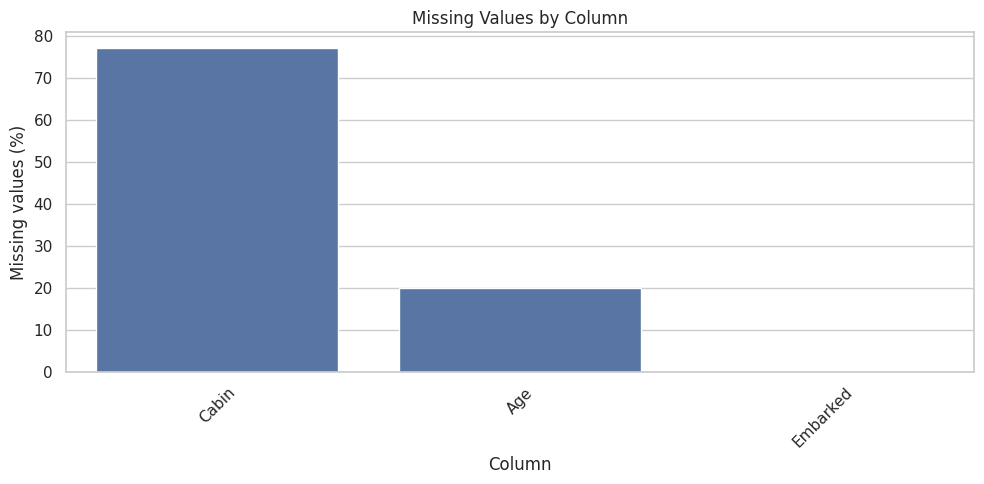

In [7]:

plt.figure(figsize=(10, 5))
missing_plot = missing_table[missing_table["Missing Values"] > 0]
sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Percentage"]
)
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing values (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 5. Understand the target column

- `Survived = 0` means the passenger did not survive.
- `Survived = 1` means the passenger survived.


In [8]:

survival_counts = df["Survived"].value_counts().sort_index()
survival_percent = (df["Survived"].value_counts(normalize=True).sort_index() * 100).round(2)

survival_summary = pd.DataFrame({
    "Count": survival_counts,
    "Percentage": survival_percent
})
survival_summary.index = ["Did not survive", "Survived"]

display(survival_summary)


,Count,Percentage
Did not survive,549,61.62
Survived,342,38.38


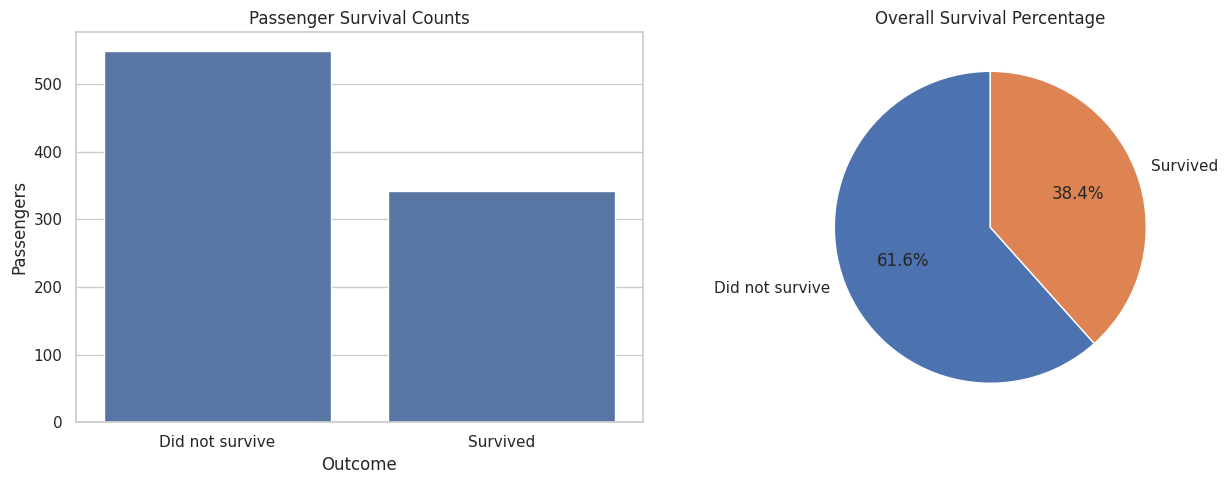

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df, x="Survived", ax=axes[0])
axes[0].set_title("Passenger Survival Counts")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Did not survive", "Survived"])
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Passengers")

axes[1].pie(
    survival_counts,
    labels=["Did not survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Overall Survival Percentage")

plt.tight_layout()
plt.show()


## 6. Exploratory Data Analysis

### 6.1 Survival by sex

,Did not survive (%),Survived (%)
Sex,,
female,25.80,74.20
male,81.11,18.89


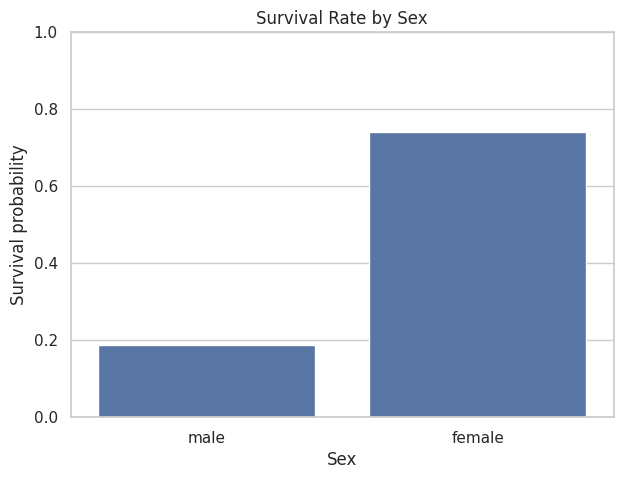

In [10]:

sex_survival = pd.crosstab(df["Sex"], df["Survived"], normalize="index") * 100
sex_survival.columns = ["Did not survive (%)", "Survived (%)"]
display(sex_survival.round(2))

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="Sex", y="Survived", errorbar=None)
plt.title("Survival Rate by Sex")
plt.ylabel("Survival probability")
plt.xlabel("Sex")
plt.ylim(0, 1)
plt.show()


### 6.2 Survival by passenger class

,Passengers,Survival Rate (%)
Pclass,,
1,216,62.96
2,184,47.28
3,491,24.24


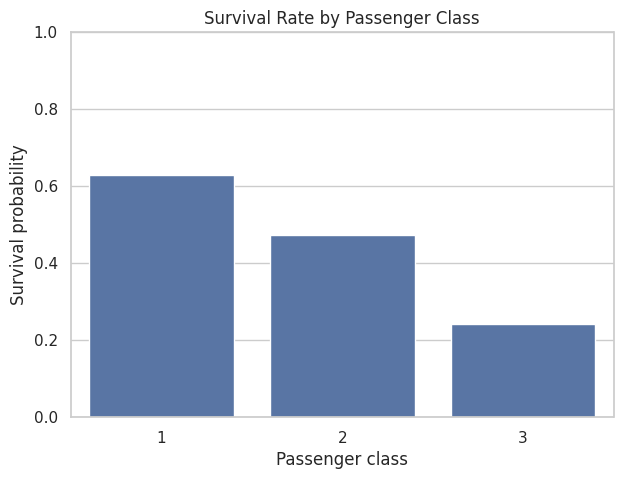

In [11]:

class_survival = df.groupby("Pclass")["Survived"].agg(["count", "mean"])
class_survival["mean"] = (class_survival["mean"] * 100).round(2)
class_survival.columns = ["Passengers", "Survival Rate (%)"]
display(class_survival)

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="Pclass", y="Survived", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger class")
plt.ylabel("Survival probability")
plt.ylim(0, 1)
plt.show()


### 6.3 Survival by sex and passenger class

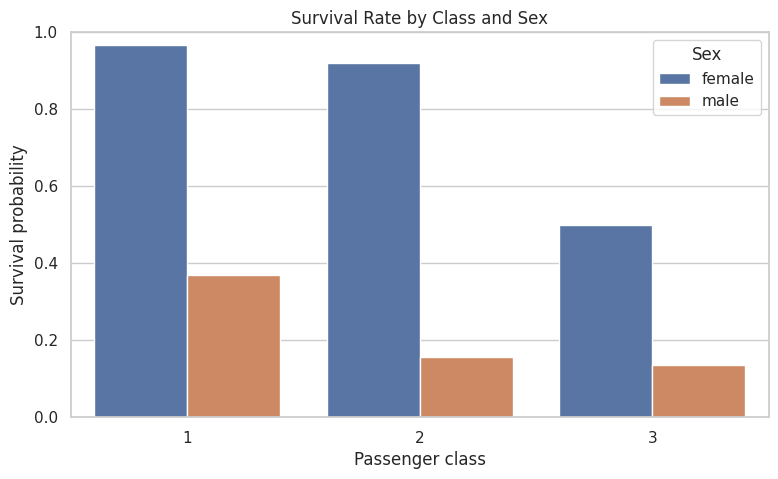

In [12]:

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex", errorbar=None)
plt.title("Survival Rate by Class and Sex")
plt.xlabel("Passenger class")
plt.ylabel("Survival probability")
plt.ylim(0, 1)
plt.show()


### 6.4 Age distribution

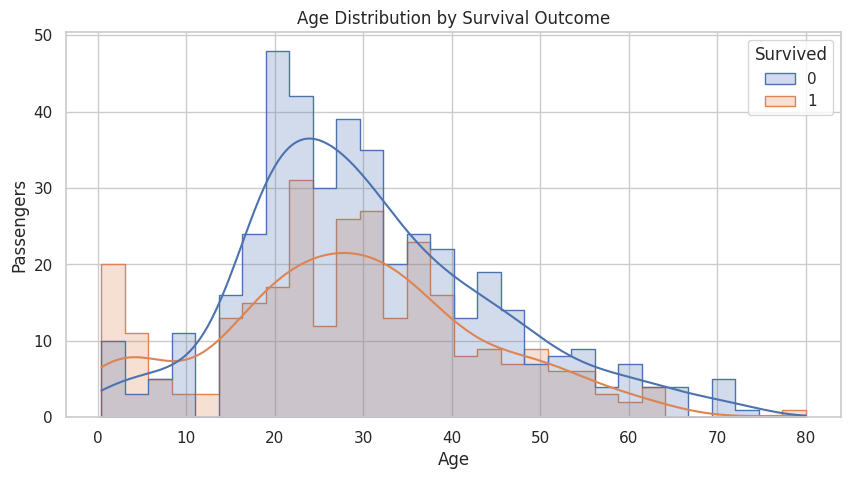

In [13]:

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Survival Outcome")
plt.xlabel("Age")
plt.ylabel("Passengers")
plt.show()


### 6.5 Fare distribution

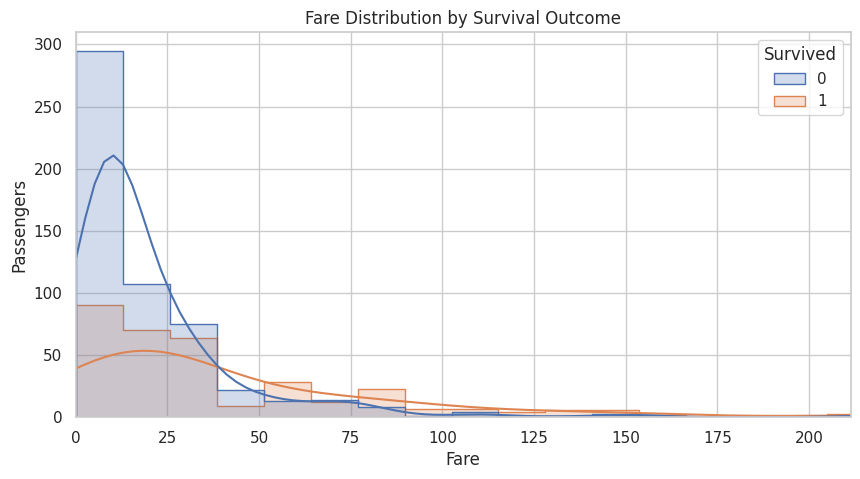

In [14]:

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Fare",
    hue="Survived",
    bins=40,
    kde=True,
    element="step"
)
plt.xlim(0, df["Fare"].quantile(0.98))
plt.title("Fare Distribution by Survival Outcome")
plt.xlabel("Fare")
plt.ylabel("Passengers")
plt.show()


### 6.6 Survival by embarkation port

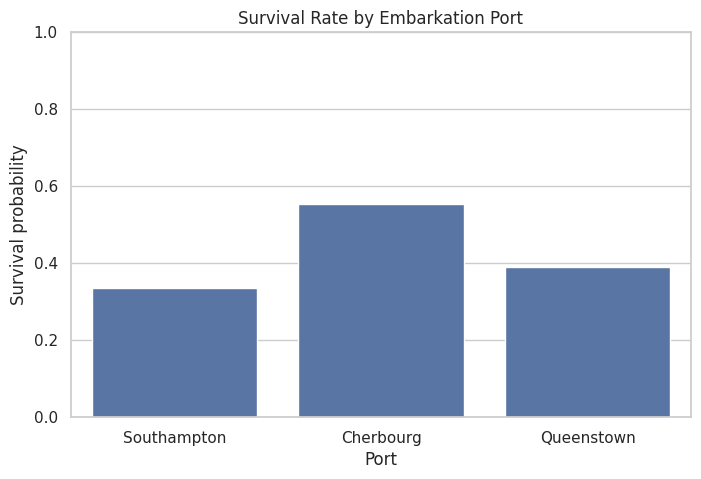

In [15]:

embarked_names = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton"
}

embarked_plot_df = df.copy()
embarked_plot_df["EmbarkedName"] = embarked_plot_df["Embarked"].map(embarked_names)

plt.figure(figsize=(8, 5))
sns.barplot(data=embarked_plot_df, x="EmbarkedName", y="Survived", errorbar=None)
plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Port")
plt.ylabel("Survival probability")
plt.ylim(0, 1)
plt.show()


### 6.7 Family size and survival

,Passengers,Survival Rate (%)
FamilySize,,
1,537,30.35
2,161,55.28
3,102,57.84
4,29,72.41
5,15,20.00
6,22,13.64
7,12,33.33
8,6,0.00
11,7,0.00


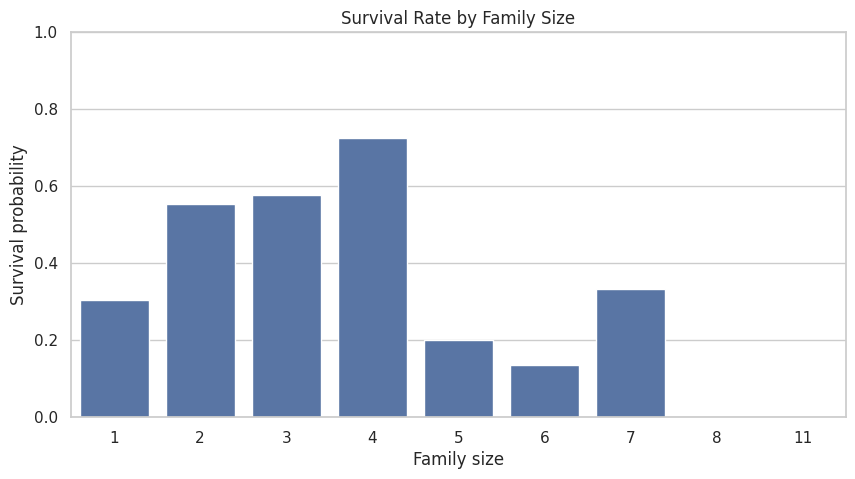

In [16]:

eda_df = df.copy()
eda_df["FamilySize"] = eda_df["SibSp"] + eda_df["Parch"] + 1

family_survival = eda_df.groupby("FamilySize")["Survived"].agg(["count", "mean"])
family_survival["mean"] = (family_survival["mean"] * 100).round(2)
family_survival.columns = ["Passengers", "Survival Rate (%)"]
display(family_survival)

plt.figure(figsize=(10, 5))
sns.barplot(data=eda_df, x="FamilySize", y="Survived", errorbar=None)
plt.title("Survival Rate by Family Size")
plt.xlabel("Family size")
plt.ylabel("Survival probability")
plt.ylim(0, 1)
plt.show()


### 6.8 Correlation heatmap

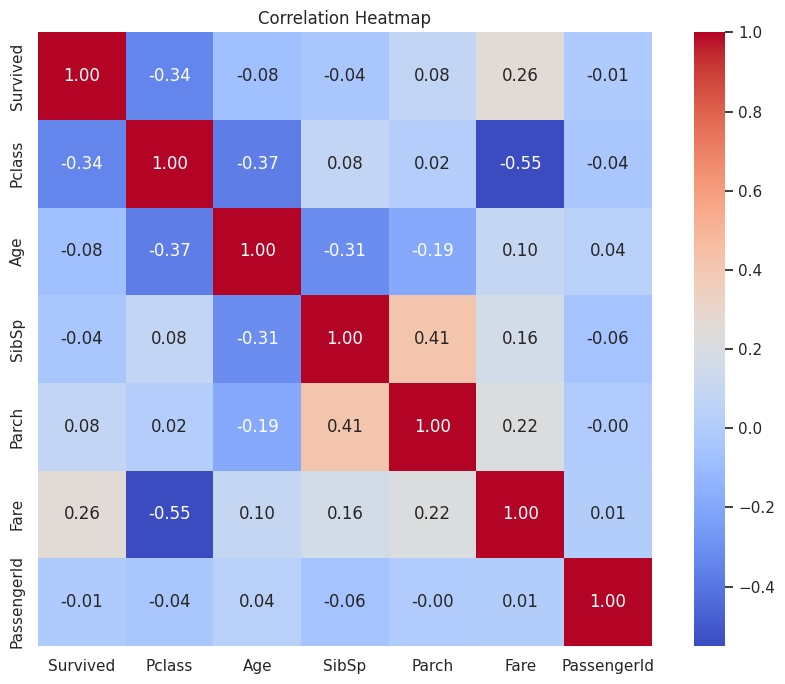

In [17]:

numeric_columns = [
    "Survived", "Pclass", "Age", "SibSp",
    "Parch", "Fare", "PassengerId"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 7. Feature engineering

In [18]:

model_df = df.copy()

# Family-related features
model_df["FamilySize"] = model_df["SibSp"] + model_df["Parch"] + 1
model_df["IsAlone"] = (model_df["FamilySize"] == 1).astype(int)

# Extract title from passenger name
model_df["Title"] = model_df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

# Combine uncommon titles
rare_titles = model_df["Title"].value_counts()
rare_titles = rare_titles[rare_titles < 10].index
model_df["Title"] = model_df["Title"].replace(rare_titles, "Rare")

# Cabin availability can be useful even when cabin number is missing
model_df["HasCabin"] = model_df["Cabin"].notna().astype(int)

# Deck letter from cabin
model_df["Deck"] = model_df["Cabin"].str[0].fillna("Unknown")

display(model_df[[
    "Name", "Title", "FamilySize", "IsAlone",
    "Cabin", "HasCabin", "Deck"
]].head(10))


,Name,Title,FamilySize,IsAlone,Cabin,HasCabin,Deck
0,"Braund, Mr. Owen Harris",Mr,2,0,NaN,0,Unknown
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,C85,1,C
2,"Heikkinen, Miss. Laina",Miss,1,1,NaN,0,Unknown
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,C123,1,C
4,"Allen, Mr. William Henry",Mr,1,1,NaN,0,Unknown
5,"Moran, Mr. James",Mr,1,1,NaN,0,Unknown
6,"McCarthy, Mr. Timothy J",Mr,1,1,E46,1,E
7,"Palsson, Master. Gosta Leonard",Master,5,0,NaN,0,Unknown
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs,3,0,NaN,0,Unknown
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs,2,0,NaN,0,Unknown


## 8. Select model features and target

In [19]:

features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "HasCabin",
    "Deck"
]

target = "Survived"

X = model_df[features]
y = model_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())


Feature matrix shape: (891, 10)
Target shape: (891,)


,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Title,HasCabin,Deck
0,3,male,22.0,7.2500,S,2,0,Mr,0,Unknown
1,1,female,38.0,71.2833,C,2,0,Mrs,1,C
2,3,female,26.0,7.9250,S,1,1,Miss,0,Unknown
3,1,female,35.0,53.1000,S,2,0,Mrs,1,C
4,3,male,35.0,8.0500,S,1,1,Mr,0,Unknown


## 9. Split training and testing data

In [20]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 712
Testing rows: 179


## 10. Build preprocessing pipeline

In [21]:

numeric_features = [
    "Age",
    "Fare",
    "FamilySize"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "IsAlone",
    "Title",
    "HasCabin",
    "Deck"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ]
)

print("✅ Preprocessing pipeline created")


✅ Preprocessing pipeline created


## 11. Train and compare multiple models

In [22]:

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=7,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

trained_pipelines = {}
comparison_rows = []

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

    comparison_rows.append(metrics)
    trained_pipelines[model_name] = pipeline

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    "ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(comparison_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1 Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.849,0.828,0.768,0.797,0.869
1,Gradient Boosting,0.816,0.800,0.696,0.744,0.847
2,Random Forest,0.804,0.750,0.739,0.745,0.847


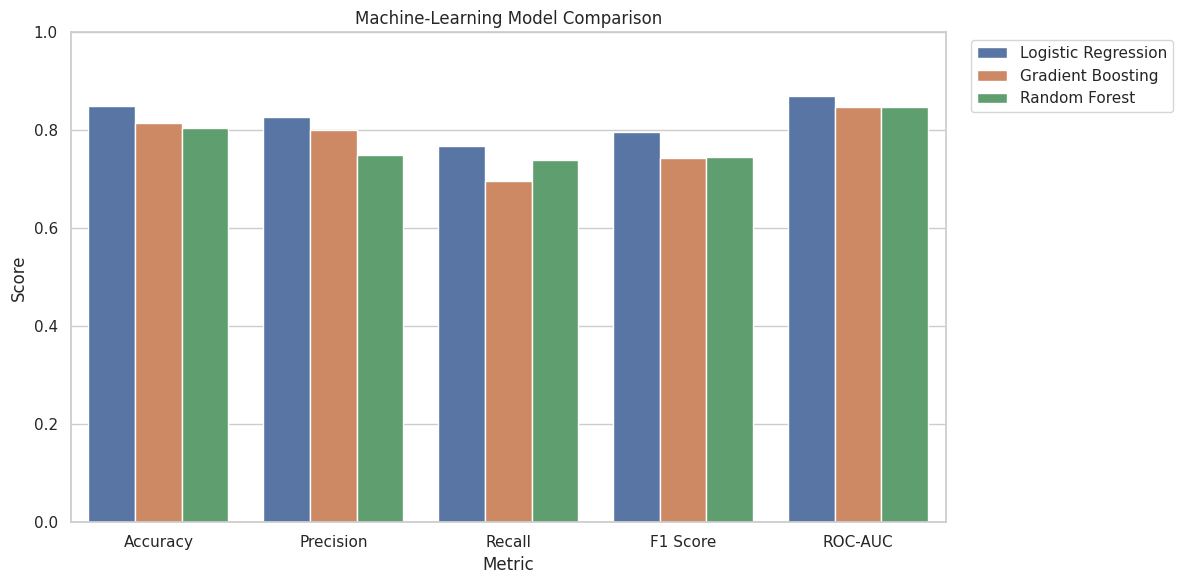

In [23]:

comparison_long = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model"
)
plt.title("Machine-Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 12. Select the best model automatically

In [24]:

best_model_name = comparison_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("🏆 Best model:", best_model_name)
print(
    "Best ROC-AUC:",
    round(comparison_df.iloc[0]["ROC-AUC"], 4)
)


🏆 Best model: Logistic Regression
Best ROC-AUC: 0.8692


## 13. Detailed evaluation of the best model

In [25]:

best_predictions = best_model.predict(X_test)
best_probabilities = best_model.predict_proba(X_test)[:, 1]

print("Classification report:")
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Did not survive", "Survived"]
    )
)


Classification report:
                 precision    recall  f1-score   support

Did not survive       0.86      0.90      0.88       110
       Survived       0.83      0.77      0.80        69

       accuracy                           0.85       179
      macro avg       0.84      0.83      0.84       179
   weighted avg       0.85      0.85      0.85       179



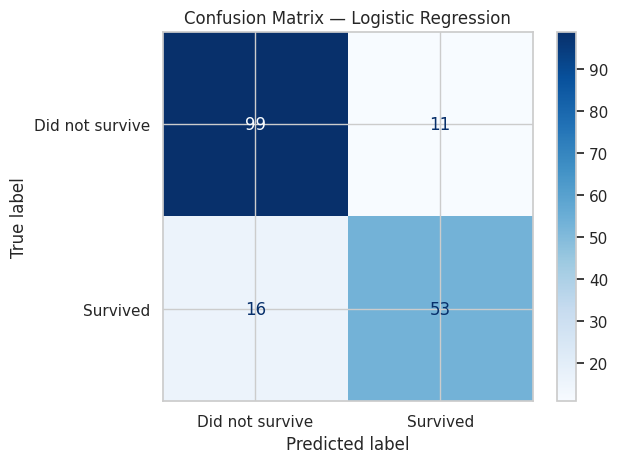

In [26]:

cm = confusion_matrix(y_test, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Did not survive", "Survived"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()


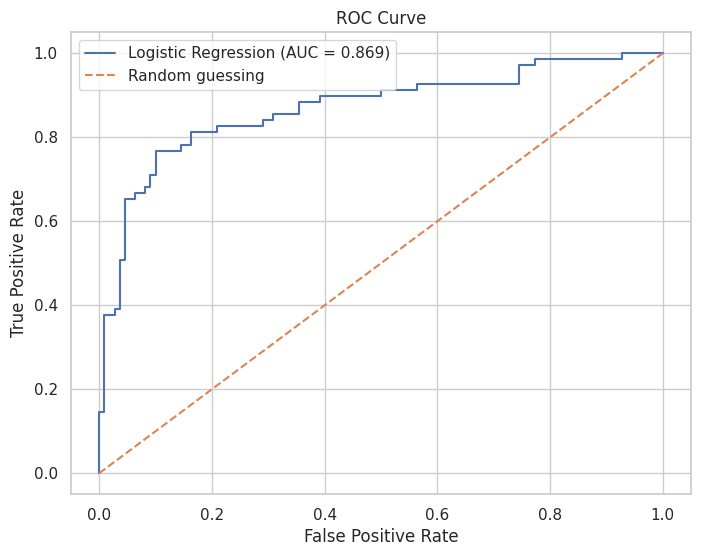

In [27]:

fpr, tpr, thresholds = roc_curve(y_test, best_probabilities)
auc_score = roc_auc_score(y_test, best_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## 14. Cross-validation score

In [28]:

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4))
print("CV standard deviation:", round(cv_scores.std(), 4))


Cross-validation scores: [0.8268 0.8258 0.8146 0.8258 0.8539]
Mean CV accuracy: 0.8294
CV standard deviation: 0.0131


## 15. Feature importance or model coefficients

,Feature,Absolute coefficient
13,categorical__Title_Master,1.226781
15,categorical__Title_Mr,1.225129
6,categorical__Sex_female,0.897413
24,categorical__Deck_E,0.870651
7,categorical__Sex_male,0.862127
23,categorical__Deck_D,0.749045
26,categorical__Deck_G,0.719450
2,numeric__FamilySize,0.640662
5,categorical__Pclass_3,0.635417
16,categorical__Title_Mrs,0.511528


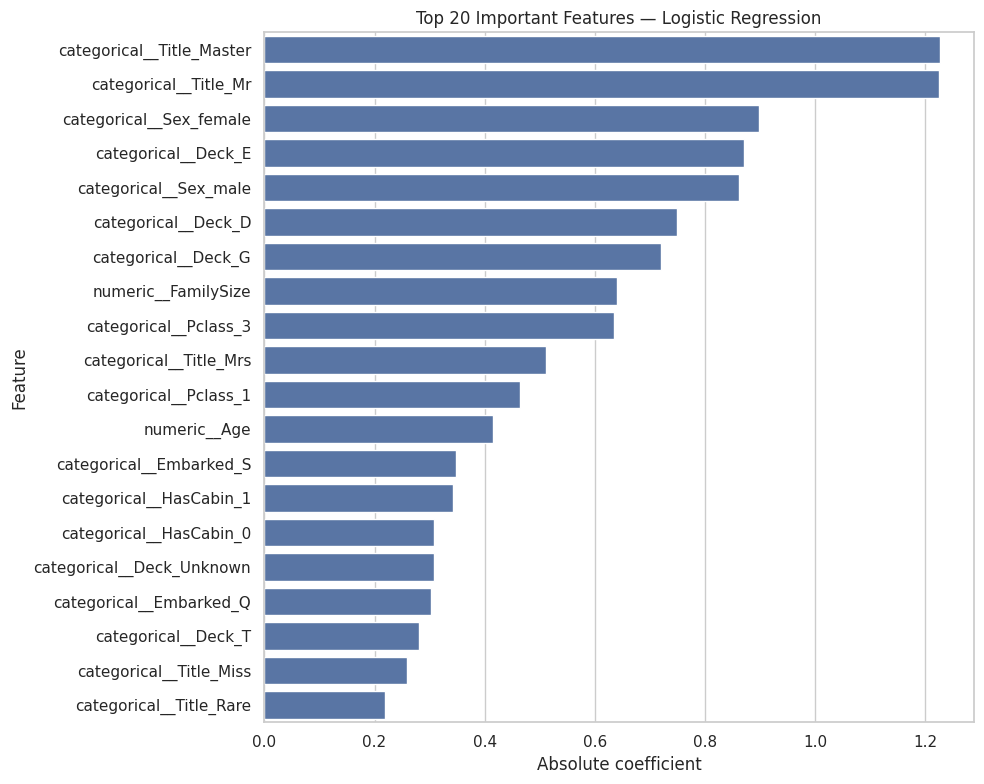

In [29]:

fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_estimator = best_model.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

if hasattr(fitted_estimator, "feature_importances_"):
    importance_values = fitted_estimator.feature_importances_
    importance_label = "Importance"
elif hasattr(fitted_estimator, "coef_"):
    importance_values = np.abs(fitted_estimator.coef_[0])
    importance_label = "Absolute coefficient"
else:
    importance_values = None

if importance_values is not None:
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        importance_label: importance_values
    }).sort_values(importance_label, ascending=False).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=importance_df,
        x=importance_label,
        y="Feature"
    )
    plt.title(f"Top 20 Important Features — {best_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is unavailable for this model.")


## 16. Add predictions to the test data

In [30]:

test_results = X_test.copy()
test_results["ActualOutcome"] = y_test.values
test_results["PredictedOutcome"] = best_predictions
test_results["SurvivalProbability"] = best_probabilities
test_results["NotSurviveProbability"] = 1 - best_probabilities

test_results["ActualLabel"] = test_results["ActualOutcome"].map({
    0: "Did not survive",
    1: "Survived"
})

test_results["PredictedLabel"] = test_results["PredictedOutcome"].map({
    0: "Did not survive",
    1: "Survived"
})

display(
    test_results[[
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "ActualLabel",
        "PredictedLabel",
        "SurvivalProbability",
        "NotSurviveProbability"
    ]].head(20)
)


,Pclass,Sex,Age,Fare,ActualLabel,PredictedLabel,SurvivalProbability,NotSurviveProbability
565,3,male,24.0,24.1500,Did not survive,Did not survive,0.052503,0.947497
160,3,male,44.0,16.1000,Did not survive,Did not survive,0.040716,0.959284
553,3,male,22.0,7.2250,Survived,Did not survive,0.132739,0.867261
860,3,male,41.0,14.1083,Did not survive,Did not survive,0.030005,0.969995
241,3,female,NaN,15.5000,Survived,Survived,0.669654,0.330346
559,3,female,36.0,17.4000,Survived,Survived,0.644882,0.355118
387,2,female,36.0,13.0000,Survived,Survived,0.698543,0.301457
536,1,male,45.0,26.5500,Did not survive,Did not survive,0.474738,0.525262
698,1,male,49.0,110.8833,Did not survive,Did not survive,0.273780,0.726220
99,2,male,34.0,26.0000,Did not survive,Did not survive,0.123659,0.876341



## 17. Predict a new passenger

Change the values below and run the cell.

### Input help

- `Pclass`: 1, 2, or 3  
- `Sex`: `male` or `female`  
- `Embarked`: `C`, `Q`, or `S`  
- `FamilySize`: passenger + siblings/spouse + parents/children  
- `IsAlone`: 1 when alone, otherwise 0  
- `Title`: Mr, Mrs, Miss, Master, or Rare  
- `HasCabin`: 1 if cabin is known, otherwise 0  
- `Deck`: A–G or Unknown  


In [31]:

new_passenger = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "male",
    "Age": 25,
    "Fare": 7.25,
    "Embarked": "S",
    "FamilySize": 1,
    "IsAlone": 1,
    "Title": "Mr",
    "HasCabin": 0,
    "Deck": "Unknown"
}])

prediction = best_model.predict(new_passenger)[0]
probability = best_model.predict_proba(new_passenger)[0]

survival_probability = probability[1] * 100
not_survive_probability = probability[0] * 100

print("Prediction:", "SURVIVED" if prediction == 1 else "DID NOT SURVIVE")
print(f"Survival chance: {survival_probability:.2f}%")
print(f"Not-survive chance: {not_survive_probability:.2f}%")


Prediction: DID NOT SURVIVE
Survival chance: 8.31%
Not-survive chance: 91.69%


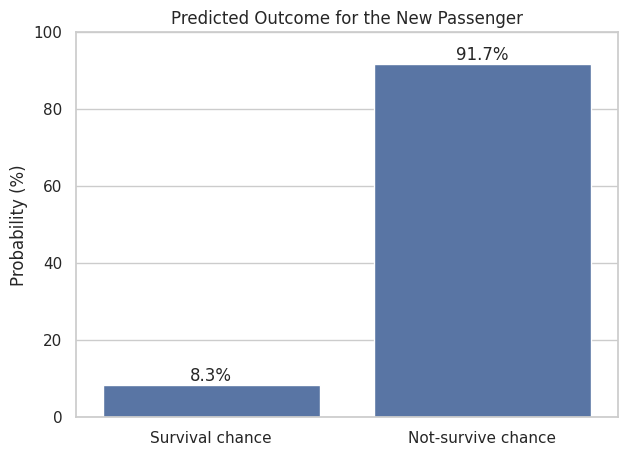

In [32]:

labels = ["Survival chance", "Not-survive chance"]
values = [survival_probability, not_survive_probability]

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=values)
plt.title("Predicted Outcome for the New Passenger")
plt.ylabel("Probability (%)")
plt.ylim(0, 100)

for index, value in enumerate(values):
    plt.text(index, value + 1, f"{value:.1f}%", ha="center")

plt.show()


## 18. Optional interactive passenger predictor

In [33]:

import ipywidgets as widgets
from IPython.display import display, clear_output

pclass_widget = widgets.Dropdown(
    options=[1, 2, 3],
    value=3,
    description="Class:"
)

sex_widget = widgets.Dropdown(
    options=["male", "female"],
    value="male",
    description="Sex:"
)

age_widget = widgets.FloatSlider(
    value=25,
    min=0.5,
    max=80,
    step=0.5,
    description="Age:"
)

fare_widget = widgets.FloatSlider(
    value=20,
    min=0,
    max=520,
    step=1,
    description="Fare:"
)

embarked_widget = widgets.Dropdown(
    options=["S", "C", "Q"],
    value="S",
    description="Embarked:"
)

family_widget = widgets.IntSlider(
    value=1,
    min=1,
    max=11,
    description="Family:"
)

title_widget = widgets.Dropdown(
    options=["Mr", "Mrs", "Miss", "Master", "Rare"],
    value="Mr",
    description="Title:"
)

cabin_widget = widgets.Dropdown(
    options=[("No cabin", 0), ("Cabin known", 1)],
    value=0,
    description="Cabin:"
)

deck_widget = widgets.Dropdown(
    options=["Unknown", "A", "B", "C", "D", "E", "F", "G"],
    value="Unknown",
    description="Deck:"
)

predict_button = widgets.Button(
    description="Predict survival",
    button_style="success"
)

output_widget = widgets.Output()

def predict_interactively(button):
    with output_widget:
        clear_output()

        family_size = family_widget.value
        is_alone = int(family_size == 1)
        has_cabin = cabin_widget.value
        deck = deck_widget.value if has_cabin == 1 else "Unknown"

        passenger = pd.DataFrame([{
            "Pclass": pclass_widget.value,
            "Sex": sex_widget.value,
            "Age": age_widget.value,
            "Fare": fare_widget.value,
            "Embarked": embarked_widget.value,
            "FamilySize": family_size,
            "IsAlone": is_alone,
            "Title": title_widget.value,
            "HasCabin": has_cabin,
            "Deck": deck
        }])

        predicted_class = best_model.predict(passenger)[0]
        predicted_probability = best_model.predict_proba(passenger)[0]

        survived_pct = predicted_probability[1] * 100
        not_survived_pct = predicted_probability[0] * 100

        print(
            "Predicted result:",
            "SURVIVED" if predicted_class == 1 else "DID NOT SURVIVE"
        )
        print(f"Survival chance: {survived_pct:.2f}%")
        print(f"Not-survive chance: {not_survived_pct:.2f}%")

predict_button.on_click(predict_interactively)

display(
    pclass_widget,
    sex_widget,
    age_widget,
    fare_widget,
    embarked_widget,
    family_widget,
    title_widget,
    cabin_widget,
    deck_widget,
    predict_button,
    output_widget
)


Dropdown(description='Class:', index=2, options=(1, 2, 3), value=3)

Dropdown(description='Sex:', options=('male', 'female'), value='male')

FloatSlider(value=25.0, description='Age:', max=80.0, min=0.5, step=0.5)

FloatSlider(value=20.0, description='Fare:', max=520.0, step=1.0)

Dropdown(description='Embarked:', options=('S', 'C', 'Q'), value='S')

...

Dropdown(description='Title:', options=('Mr', 'Mrs', 'Miss', 'Master', 'Rare'), value='Mr')

Dropdown(description='Cabin:', options=(('No cabin', 0), ('Cabin known', 1)), value=0)

Dropdown(description='Deck:', options=('Unknown', 'A', 'B', 'C', 'D', 'E', 'F', 'G'), value='Unknown')

Button(button_style='success', description='Predict survival', style=ButtonStyle())

Output()

## 19. Predict every passenger in the full dataset

In [34]:

full_probabilities = best_model.predict_proba(X)[:, 1]
full_predictions = best_model.predict(X)

final_output = df.copy()
final_output["PredictedSurvived"] = full_predictions
final_output["PredictedSurvivalChance"] = full_probabilities
final_output["PredictedNotSurviveChance"] = 1 - full_probabilities
final_output["PredictedOutcome"] = final_output["PredictedSurvived"].map({
    0: "Did not survive",
    1: "Survived"
})

display(final_output[[
    "PassengerId",
    "Name",
    "Sex",
    "Age",
    "Pclass",
    "Survived",
    "PredictedOutcome",
    "PredictedSurvivalChance",
    "PredictedNotSurviveChance"
]].head(20))


,PassengerId,Name,Sex,Age,Pclass,Survived,PredictedOutcome,PredictedSurvivalChance,PredictedNotSurviveChance
0,1,"Braund, Mr. Owen Harris",male,22.0,3,0,Did not survive,0.076091,0.923909
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,1,Survived,0.957227,0.042773
2,3,"Heikkinen, Miss. Laina",female,26.0,3,1,Survived,0.573364,0.426636
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,1,Survived,0.936991,0.063009
4,5,"Allen, Mr. William Henry",male,35.0,3,0,Did not survive,0.062088,0.937912
5,6,"Moran, Mr. James",male,NaN,3,0,Did not survive,0.135178,0.864822
6,7,"McCarthy, Mr. Timothy J",male,54.0,1,0,Did not survive,0.448184,0.551816
7,8,"Palsson, Master. Gosta Leonard",male,2.0,3,0,Did not survive,0.363342,0.636658
8,9,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,3,1,Survived,0.611410,0.388590
9,10,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,2,1,Survived,0.932097,0.067903


## 20. Save model and results

In [35]:

MODEL_FILE = "titanic_survival_model.joblib"
RESULT_FILE = "titanic_predictions.csv"

joblib.dump(best_model, MODEL_FILE)
final_output.to_csv(RESULT_FILE, index=False)

print(f"✅ Model saved as: {MODEL_FILE}")
print(f"✅ Predictions saved as: {RESULT_FILE}")


✅ Model saved as: titanic_survival_model.joblib
✅ Predictions saved as: titanic_predictions.csv


In [36]:

# Download generated files in Google Colab.

try:
    from google.colab import files

    print("Run either download command as needed:")
    # files.download(MODEL_FILE)
    # files.download(RESULT_FILE)
except ImportError:
    print("Download commands are available only in Google Colab.")


Run either download command as needed:



## 21. Final conclusions

After running all cells, use your actual outputs to complete these conclusions:

- The dataset contains **891 passengers**.
- The project predicts passenger survival probability.
- Missing age, cabin, and embarkation values are handled automatically.
- Several graphs explain survival patterns.
- Three classification models are compared.
- The best model is selected using ROC-AUC.
- The final prediction returns:
  - Survival chance
  - Not-survive chance
  - Predicted outcome
- The model and prediction CSV can be downloaded.

### General patterns commonly seen in this dataset

- Female passengers usually had higher survival rates.
- First-class passengers usually had higher survival rates.
- Children often had better chances than many adult men.
- Fare, cabin information, family size, and embarkation port can also influence predictions.

> Machine-learning probabilities are estimates. They are not historical proof for an individual passenger.


In [37]:
import os
import matplotlib.pyplot as plt

# Folder where all graphs will be saved
GRAPH_FOLDER = "titanic_graphs"
os.makedirs(GRAPH_FOLDER, exist_ok=True)

graph_number = 1
original_show = plt.show


def save_and_show(*args, **kwargs):
    global graph_number

    # Get all currently opened figures
    figure_numbers = plt.get_fignums()

    for figure_number in figure_numbers:
        figure = plt.figure(figure_number)

        file_name = f"graph_{graph_number:02d}.png"
        file_path = os.path.join(GRAPH_FOLDER, file_name)

        figure.savefig(
            file_path,
            dpi=300,
            bbox_inches="tight",
            facecolor="white"
        )

        print(f"✅ Saved: {file_path}")
        graph_number += 1

    # Display graph normally
    original_show(*args, **kwargs)


# Replace normal plt.show() with automatic save + show
plt.show = save_and_show

print("✅ Automatic graph saving enabled")

✅ Automatic graph saving enabled


✅ Saved: titanic_graphs/graph_01.png


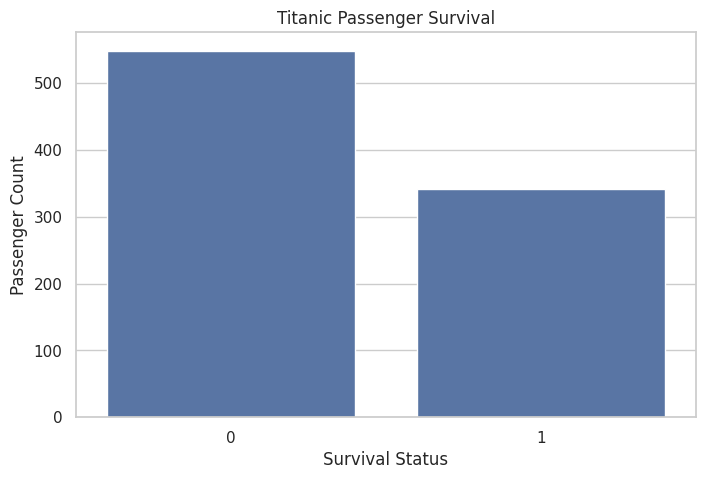

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Passenger Survival")
plt.xlabel("Survival Status")
plt.ylabel("Passenger Count")

plt.show()


In [39]:
import shutil
from google.colab import files

# Create ZIP file containing all graphs
shutil.make_archive(
    "titanic_all_graphs",
    "zip",
    GRAPH_FOLDER
)

print("✅ All graphs compressed successfully")

files.download("titanic_all_graphs.zip")

✅ All graphs compressed successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>